# 02 - Mentions over time (per ticker)

**What this does:** reads the cleaned posts, finds the stock tickers in each
post, and counts mentions per day. It makes **two graphs**:

1. **Raw mentions** - every post counts as 1.
2. **Upvote-weighted mentions** - each mention is weighted by the post's upvotes
   (score). This leans on what the crowd actually pushed up, so a few high-upvote
   posts matter more than lots of ignored ones.

It saves `data/processed/daily_ticker_counts.parquet` (with both columns), which
notebook 03 uses.

_Note:_ the first run downloads the official Nasdaq ticker list (needs internet)
and caches it under `data/reference/`.

**Ticker matching rules** (`src/extract_tickers.py`): a mention is either a
cashtag (`$GME`, any case) or a bare **ALL-CAPS** 4-5 letter word (`NVDA`)
that is in the official US ticker universe and not on the stop lists.
Lowercase words never count - "i took out a loan" is not a $LOAN mention.

In [161]:
import os, sys
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
print('project root:', ROOT)

project root: c:\Users\alexd\Desktop\GIC\RetailFlow1


In [162]:
# ============ TIME WINDOW - edit freely ============
# Keep this narrow to keep runs fast. Rough guide with ALL 15 subreddits:
#   1 year  ~ 700k posts  -> notebook 02 scan: a few minutes
#   all dates = 7.9M posts -> 02: ~30-60 min, 04 (themes): many HOURS
# Set both to None for the full 2008-2025 history.
START_DATE = '2022-01-01'   # inclusive,  'YYYY-MM-DD' or None
END_DATE   = '2023-01-01'   # EXCLUSIVE,  'YYYY-MM-DD' or None
# ====================================================

In [163]:
# ============ PARAMETERS - edit these ============
POSTS_PATH        = os.path.join(ROOT, 'data', 'processed', 'posts.parquet')
SUBREDDITS        = []      # ALL 15 subreddits (7.9M posts - the scan takes a while!)
CASHTAGS_ONLY     = False   # True = only count $TICKER (cleaner, fewer false hits)
TICKERS_TO_PLOT   = []      # e.g. ['GME', 'AMC']; [] = use the TOP_N most mentioned
TOP_N             = 6
DAILY_COUNTS_OUT  = os.path.join(ROOT, 'data', 'processed', 'daily_ticker_counts.parquet')
# ==================================================

In [164]:
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
from src.ticker_universe import load_us_ticker_universe
from src.build_mentions import build_daily_counts

# Read ONLY the columns and subreddits we need, straight from the parquet.
# The reader skips row groups that can't match, so this stays fast.
filters = []
if SUBREDDITS:
    filters.append(('subreddit', 'in', [s.lower() for s in SUBREDDITS]))
if START_DATE:
    filters.append(('date', '>=', START_DATE))
if END_DATE:
    filters.append(('date', '<', END_DATE))

posts = pq.read_table(
    POSTS_PATH,
    columns=['date', 'title', 'selftext', 'score'],
    filters=filters if filters else None,
).to_pandas()
print('posts:', f'{len(posts):,}')

# Valid US tickers (cached after first download).
universe = load_us_ticker_universe(Path(ROOT) / 'data' / 'reference', max_cache_age_days=7)
print('ticker universe size:', len(universe))

# daily now has BOTH: mention_count (raw) and weighted_count (by upvotes).
daily = build_daily_counts(posts, universe, cashtags_only=CASHTAGS_ONLY)
daily.to_parquet(DAILY_COUNTS_OUT, index=False)
print('daily count rows:', len(daily), '-> saved', DAILY_COUNTS_OUT)
daily.head()

posts: 919,076
ticker universe size: 12381


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
daily['date'] = pd.to_datetime(daily['date'])

# Decide which tickers to draw (same set for both graphs).
if TICKERS_TO_PLOT:
    chosen = TICKERS_TO_PLOT
else:
    totals = daily.groupby('ticker')['mention_count'].sum().sort_values(ascending=False)
    chosen = list(totals.head(TOP_N).index)
print('plotting:', chosen)

def plot_signal(column, title, ylabel):
    plt.figure(figsize=(12, 6))
    for ticker in chosen:
        one = daily[daily['ticker'] == ticker].sort_values('date')
        plt.plot(one['date'], one[column], marker='o', markersize=3, label=ticker)
    plt.title(title)
    plt.xlabel('date'); plt.ylabel(ylabel)
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

plotting: ['LOAN', 'CARD', 'BBBY', 'AWAY', 'COIN', 'RENT']


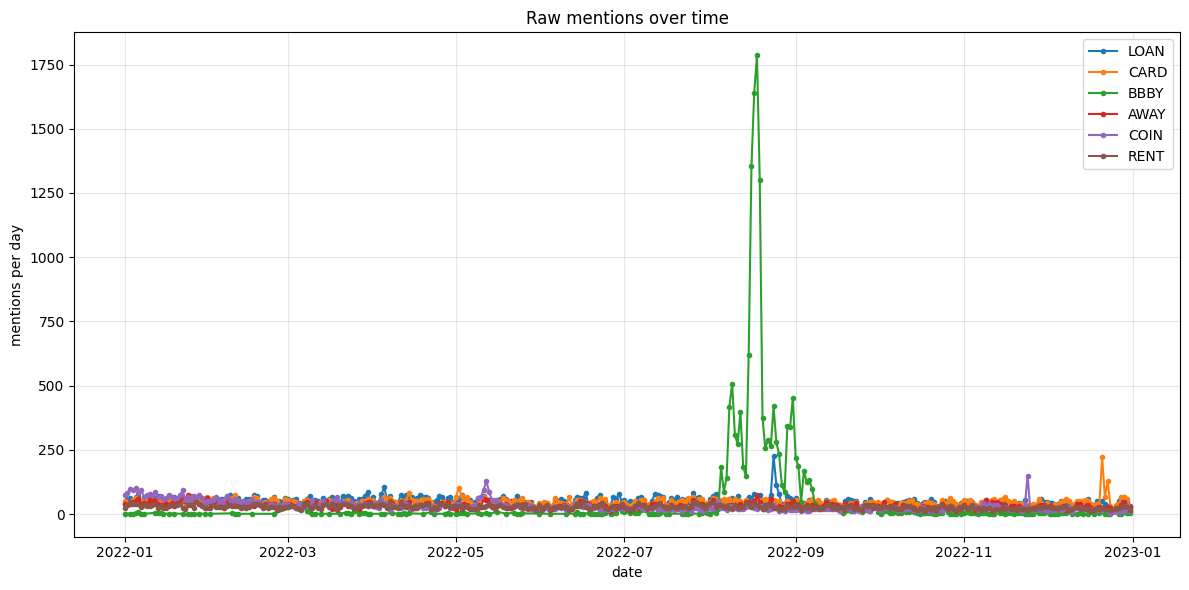

In [ ]:
# GRAPH 1 - raw mentions (every post counts as 1)
plot_signal('mention_count', 'Raw mentions over time', 'mentions per day')

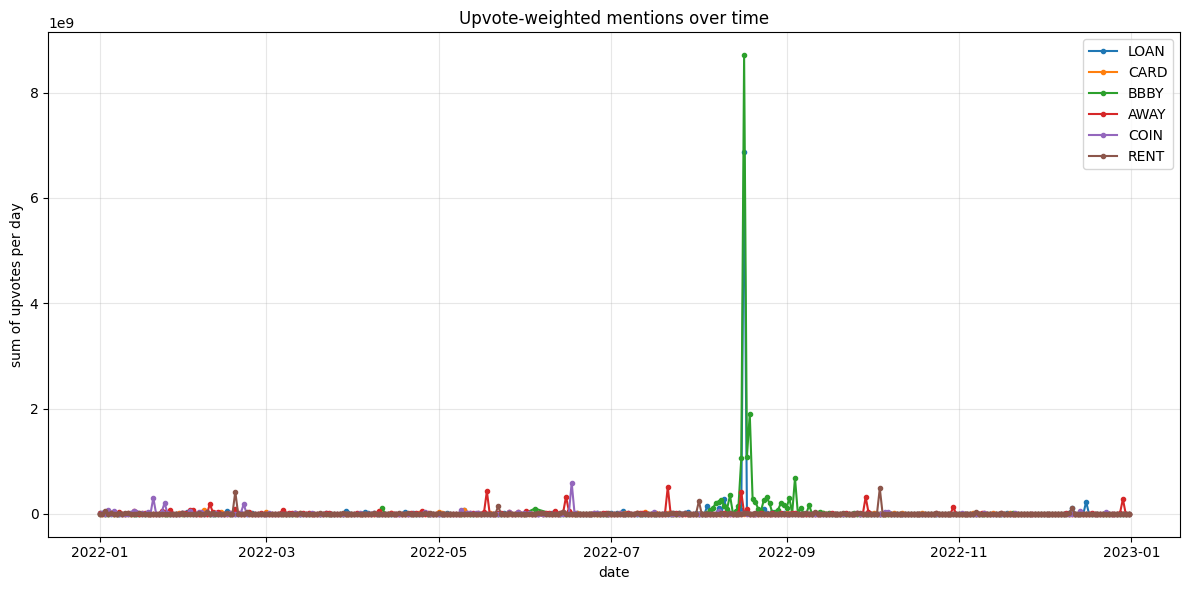

In [ ]:
# GRAPH 2 - upvote-weighted mentions (each mention weighted by the post's upvotes)
plot_signal('weighted_count', 'Upvote-weighted mentions over time', 'sum of upvotes per day')

## Raw mention counts - the actual numbers

Tables of the counts behind the plots: all-time totals per ticker, and each
year's top 10 with the year's total. Useful for sanity-checking (and for
spotting false-positive 'tickers' that are really just all-caps words - add
those to `BARE_PROSE_STOP` in `src/extract_tickers.py`).

In [ ]:
# All-time totals per ticker (top 20 by raw mention count).
alltime = (
    daily.groupby('ticker')
    .agg(total_mentions=('mention_count', 'sum'),
         days_active=('date', 'nunique'),
         busiest_day=('mention_count', 'max'))
    .sort_values('total_mentions', ascending=False)
)
alltime.head(20)

,total_mentions,days_active,busiest_day
ticker,,,
LOAN,18825,365,226
CARD,17380,365,222
BBBY,15032,251,1786
AWAY,12132,365,73
COIN,11593,365,149
RENT,10110,365,51
EARN,8378,365,65
TECH,8001,365,71
LINK,7957,365,48


In [ ]:
# Top 10 tickers per year, with the raw counts.
daily['year'] = daily['date'].dt.year
per_year = daily.groupby(['year', 'ticker'])['mention_count'].sum().reset_index()
top10 = (
    per_year.sort_values(['year', 'mention_count'], ascending=[True, False])
    .groupby('year')
    .head(10)
    .rename(columns={'mention_count': 'total_mentions'})
)
# One row per year, tickers listed with their counts - easy to scan.
for year, grp in top10.groupby('year'):
    row = ', '.join(f"{t} ({c:,})" for t, c in zip(grp['ticker'], grp['total_mentions']))
    print(f'{year}: {row}')

2022: LOAN (18,825), CARD (17,380), BBBY (15,032), AWAY (12,132), COIN (11,593), RENT (10,110), EARN (8,378), TECH (8,001), LINK (7,957), SEEM (7,846)


## Per-year view

One plot **per year**, and each year picks its **own** top tickers.

Why: upvote scores in the archive are *mature* (a 2021 viral post shows its
full 100k upvotes), so on an all-time chart old years dominate both the
ticker choice and the y-axis. Splitting by year means every year competes
only with itself.

In [ ]:
# PER-YEAR GRAPHS - each year picks its own top tickers.
YEARLY_TOP_N = 6   # tickers per year

daily['year'] = daily['date'].dt.year

def plot_year(column, ylabel):
    for year in sorted(daily['year'].unique()):
        one_year = daily[daily['year'] == year]
        # This year's OWN ranking (by the same column we're plotting).
        totals = one_year.groupby('ticker')[column].sum().sort_values(ascending=False)
        top = list(totals.head(YEARLY_TOP_N).index)
        if not top:
            continue
        plt.figure(figsize=(12, 5))
        for ticker in top:
            one = one_year[one_year['ticker'] == ticker].sort_values('date')
            plt.plot(one['date'], one[column], marker='o', markersize=2, label=ticker)
        plt.title(f'{year} - top {len(top)} tickers by {column}')
        plt.xlabel('date'); plt.ylabel(ylabel)
        plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
        plt.show()

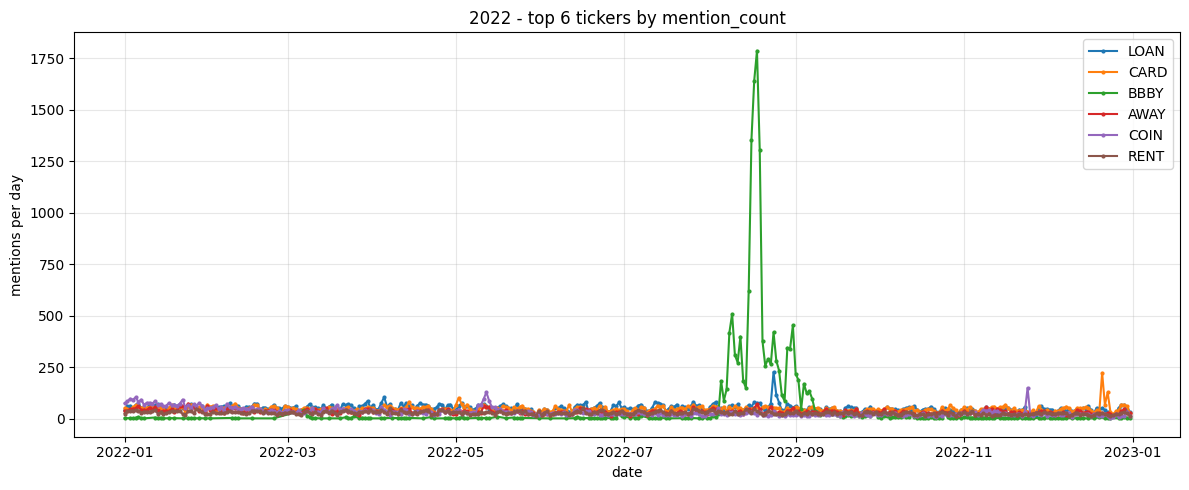

In [ ]:
# Per-year GRAPH 1 - raw mentions (every post counts as 1)
plot_year('mention_count', 'mentions per day')

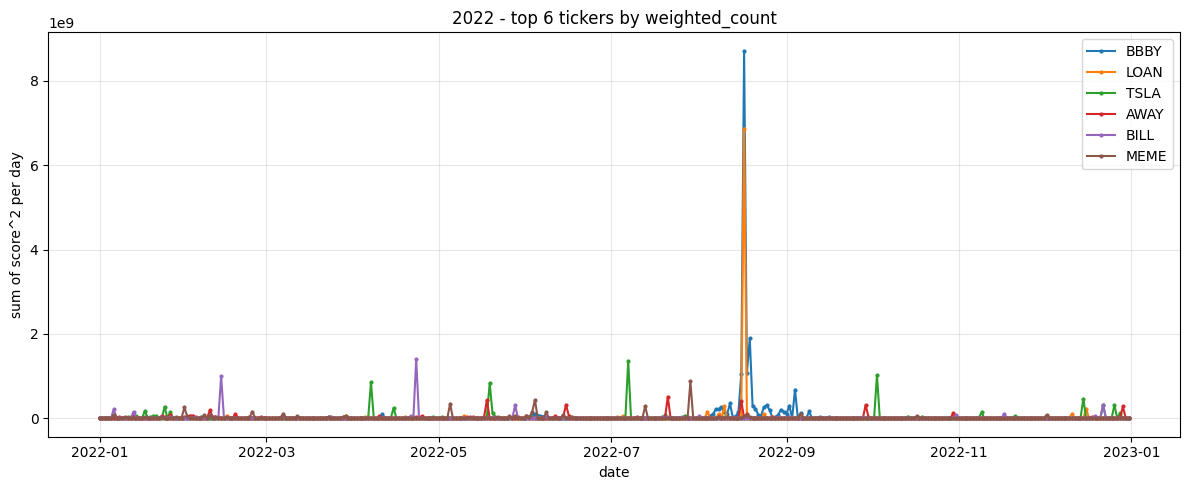

In [ ]:
# Per-year GRAPH 2 - upvote-weighted mentions
plot_year('weighted_count', 'sum of score^2 per day')

## Weekly rolling view + z-scores

Daily counts are jagged (weekday/weekend cycle, small integers). Three
progressively smoother views:

1. **7-day rolling total** - every day shows the past week's mentions, which
   erases the weekend dip entirely.
2. **Rolling z-score (time-series)** - "how unusual is this week vs the SAME
   ticker's own recent baseline?" `z = (this week - 12-week average) / 12-week
   std`. A z of +3 means ~3 standard deviations above its own normal - a
   genuine attention spike, whether the ticker usually gets 5 or 5,000
   mentions. This makes big and small tickers directly comparable.
3. **Cross-sectional z-score** - "how unusual is this ticker vs ALL OTHER
   tickers this week?" Computed on log(1+mentions) across every ticker each
   day. High cross-sectional z = the ticker dominates the conversation right
   now; rising cross-sectional z = it's climbing the leaderboard. Use the
   rolling z to time a ticker's own take-off, the cross-sectional z to rank
   tickers against each other.

**Warm-up caveat:** the rolling z needs `Z_MIN_DAYS` (28) of history before it
produces a value, so the first month of your window has NO z-score. If the
event you care about is near the start of the window (e.g. the January 2021
GME squeeze), move `START_DATE` back ~3 months so the baseline exists before
the event.

In [ ]:
# ============ ROLLING / Z-SCORE parameters ============
ROLL_DAYS   = 7      # rolling window for the weekly view (days)
Z_BASELINE  = 84     # rolling z baseline: 84 days = 12 weeks
Z_MIN_DAYS  = 28     # need at least this much history before z is computed
# =======================================================
import numpy as np

# Build a complete day x ticker matrix (missing days = 0) - the foundation
# for every rolling calculation. Rows: every calendar day. Columns: tickers.
wide = (daily.pivot_table(index='date', columns='ticker',
                          values='mention_count', aggfunc='sum')
        .asfreq('D')          # insert missing calendar days
        .fillna(0))
print('matrix:', wide.shape[0], 'days x', wide.shape[1], 'tickers')

# 1) weekly rolling total (one smooth value per day)
weekly = wide.rolling(ROLL_DAYS).sum()

# 2) rolling z-score: each ticker vs its OWN trailing baseline
roll_mean = weekly.rolling(Z_BASELINE, min_periods=Z_MIN_DAYS).mean()
roll_std  = weekly.rolling(Z_BASELINE, min_periods=Z_MIN_DAYS).std()
zscore = (weekly - roll_mean) / roll_std

# 3) cross-sectional z-score: each ticker vs ALL tickers that day,
#    on log(1+x) so mega-tickers don't define the scale
logw = np.log1p(weekly)
cs_z = logw.sub(logw.mean(axis=1), axis=0).div(logw.std(axis=1), axis=0)

matrix: 365 days x 4558 tickers


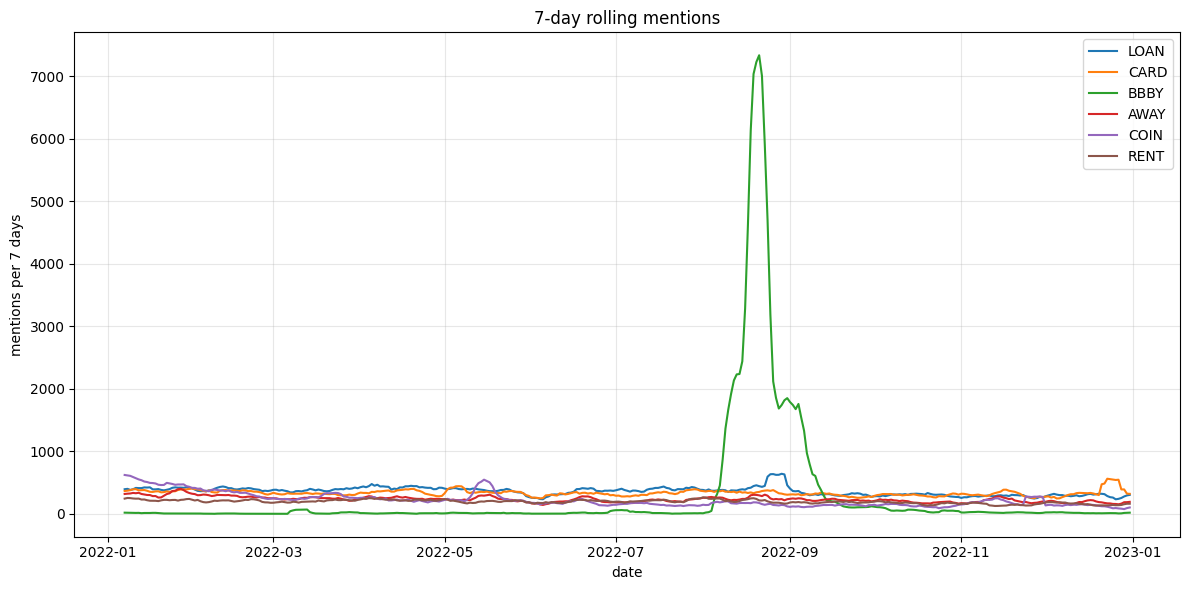

In [ ]:
# PLOT 1 - weekly rolling mentions (much smoother than the daily plots)
plt.figure(figsize=(12, 6))
for ticker in chosen:
    if ticker in weekly.columns:
        plt.plot(weekly.index, weekly[ticker], linewidth=1.5, label=ticker)
plt.title(f'{ROLL_DAYS}-day rolling mentions')
plt.xlabel('date'); plt.ylabel(f'mentions per {ROLL_DAYS} days')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

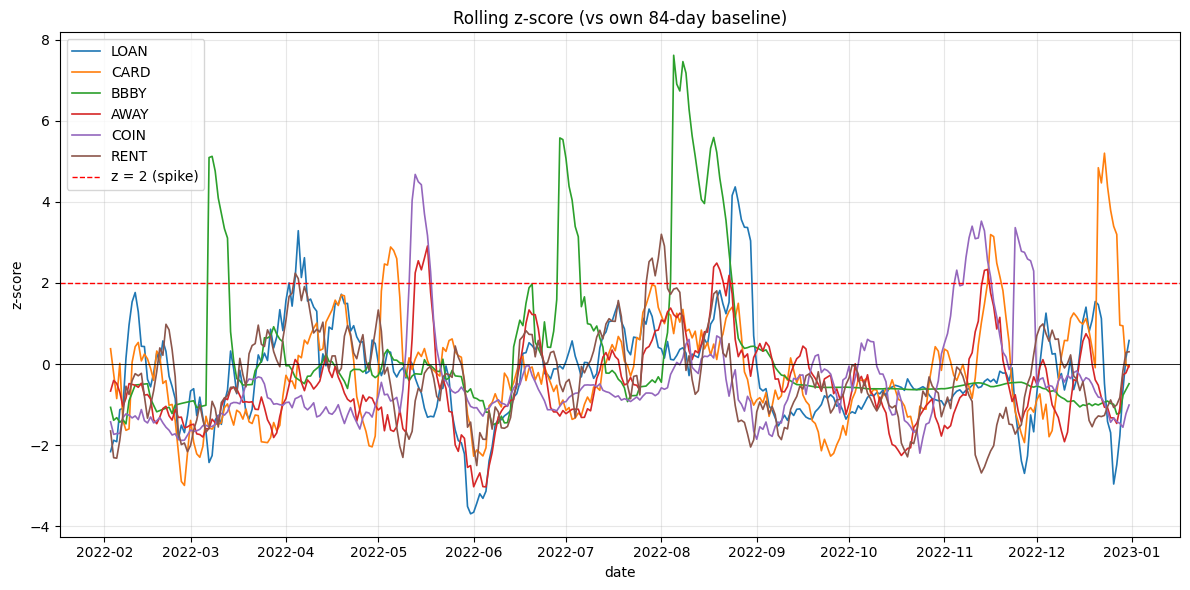

In [ ]:
# PLOT 2 - rolling z-score: spike vs the ticker's OWN recent history.
# z > 2 (dashed line) = a real attention spike for that ticker.
plt.figure(figsize=(12, 6))
for ticker in chosen:
    if ticker in zscore.columns:
        plt.plot(zscore.index, zscore[ticker], linewidth=1.2, label=ticker)
plt.axhline(2, color='red', linestyle='--', linewidth=1, label='z = 2 (spike)')
plt.axhline(0, color='black', linewidth=0.6)
plt.title(f'Rolling z-score (vs own {Z_BASELINE}-day baseline)')
plt.xlabel('date'); plt.ylabel('z-score')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

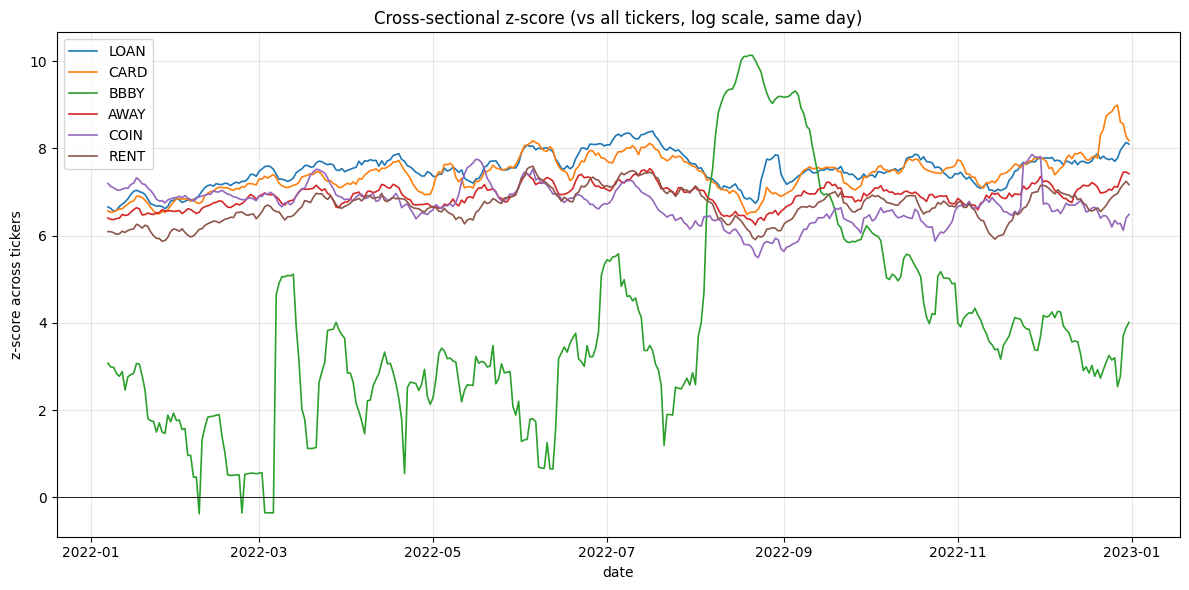

In [ ]:
# PLOT 3 - cross-sectional z-score: the ticker vs ALL other tickers that day.
# High = dominating the conversation; rising = climbing the leaderboard.
plt.figure(figsize=(12, 6))
for ticker in chosen:
    if ticker in cs_z.columns:
        plt.plot(cs_z.index, cs_z[ticker], linewidth=1.2, label=ticker)
plt.axhline(0, color='black', linewidth=0.6)
plt.title('Cross-sectional z-score (vs all tickers, log scale, same day)')
plt.xlabel('date'); plt.ylabel('z-score across tickers')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()